# Primer Entregable del Proyecto de Investigación
### Selección de Base de Datos, Análisis Exploratorio e Implementación de Modelo Base (Ruta A: Clasificación)

**Autor:** Andrés Duarte Chaves  
**Docente:** Dr. Lihki Rubio  
**Programa:** Maestría en Ingeniería Biomédica  
**Fecha:** Septiembre de 2026  

---

## 1. Base de Datos y Definición del Problema de Investigación

### 1.1. Contexto Fisiológico y Formulación del Problema
La caries dental es una patología crónica multifactorial caracterizada por la desmineralización ácida localizada de los tejidos duros del diente (esmalte y dentina), mediada por la disbiosis de la biopelícula oral ante la exposición a carbohidratos fermentables y modulada por la respuesta inmunológica, metabólica y salival del huésped.

El problema consiste en clasificar la presencia activa de **caries dental (`dental caries = 1`)** frente a individuos sanos (**`dental caries = 0`**) a partir de chequeos preventivos integrales que combinan analítica sanguínea, antropometría, hábitos de consumo y evaluación estomatológica.

### 1.2. Justificación y Fuente del Dataset
* **Dataset Oficial:** *Body Signal of Smoking / National Health Checkup* (`smoking.csv`).
* **Fuente:** Repositorio Kaggle (Korean National Health Insurance Service - KNHIS). Licencia: CC0 Public Domain.
* **Tamaño Muestral:** $n = 55{,}692$ registros ($n \gg 20{,}000$, cumpliendo holgadamente el criterio de la rúbrica).
* **Estructura:** Datos transversales (*cross-sectional*). Cada fila representa una evaluación independiente de un adulto único, sin componentes longitudinales de panel ni coordenadas espaciales.
* **Relación n/p:** Con $p = 22$ covariables predictoras primarias, $n/p \approx 2{,}531:1$, garantizando grados de libertad suficientes y descartando sobreparametrización.
* **Calidad y Ética:** Registros anonimizados sin identificadores personales directos. Mecanismo de faltantes **MAR (*Missing at Random*)** por criterios etarios oficiales del chequeo preventivo.

### 1.3. Análisis del Desbalance del Target y Reserva Preventiva
* **Prevalencia:** $21.33\%$ de casos positivos ($n=11{,}881$) frente a $78.67\%$ de controles sanos ($n=43{,}811$).
* **Implicación Metodológica:** El desbalance inhabilita al *Accuracy* como criterio de optimización; predecir siempre la clase mayoritaria daría un $78.67\%$ sin valor clínico. Por ende, la evaluación se fundamenta en **ROC AUC**, **Precision-Recall (PR AUC)** y **F1-Score**.
* **Regla de Oro:** La partición estratificada 80/20 ($n_{\text{train}}=44{,}553$, $n_{\text{test}}=11{,}139$) se ejecutó preventivamente **antes** de cualquier cálculo descriptivo o preprocesamiento.


In [ ]:
# Partición Estratificada Preventiva (80/20)
display(df_part)

,Subconjunto,Observaciones,Casos Caries (1),Prevalencia (%)
0,Train (80%),44553,9505,21.33%
1,Test (20%),11139,2376,21.33%
2,Total,55692,11881,21.33%


## 2. Análisis Exploratorio de Datos (EDA)

### 2.1. Regla de Oro Metodológica: Reserva Preventiva del Conjunto de Prueba
La división estratificada 80/20 se realizó **antes** de calcular estadísticas, umbrales de atípicos o transformaciones, preservando al conjunto de prueba ($n=11{,}139$) completamente ciego para evitar fuga de información (*data leakage*).

### 2.2. Análisis Univariado y Criterio de Tukey ($1.5 \times \text{IQR}$)
Se calculan estadísticas descriptivas robustas y la cuantificación de atípicos univariados bajo el criterio de Tukey:


### 2.2. Interpretación Exhaustiva del Análisis Univariado y Criterio de Tukey
1. **Asimetría Marcada en el Perfil Hepático y Metabólico:** Se evidencia asimetría severa en aminotransferasas (`ALT` con *skewness* 36.34, curtosis 2429.53; `AST` con 24.91; y `Gtp` con 6.70). En fisiología clínica, estas colas derechas extendidas no constituyen errores de registro ni artefactos de medición, sino la manifestación patológica de daño hepatocelular, esteatosis hepática no alcohólica o consumo crónico de alcohol en la cohorte adulta.
2. **Atípicos de Tukey:** La glucemia en ayunas (`fasting blood sugar`) presenta un $5.91\%$ de valores fuera del rango $[Q_1 - 1.5\text{IQR}, Q_3 + 1.5\text{IQR}]$, correspondiente a individuos con síndrome metabólico o diabetes mellitus tipo 2 no controlada. Dado que estos registros representan condiciones clínicas reales y de alta relevancia biológica, **no se descartan**, sino que se tratan dentro del Pipeline de modelado mediante estandarización robusta.
3. **Distribución Antropométrica:** Estatura y peso presentan morfologías unimodales con baja asimetría, representativas de la población general adulta.


In [ ]:
# Estadísticos robustos sobre Train Set
display(df_tukey)

,Variable,Media,Mediana,IQR,Skew,Kurtosis,Atipicos,% Atip
0,age,44.19,40.0,15.0,0.26,-0.17,234,0.53%
1,height(cm),164.67,165.0,10.0,-0.14,-0.62,190,0.43%
2,weight(kg),65.85,65.0,20.0,0.54,0.32,159,0.36%
3,waist(cm),82.04,82.0,12.0,0.24,0.14,396,0.89%
4,systolic,121.46,120.0,18.0,0.44,1.14,521,1.17%
5,relaxation,76.00,76.0,12.0,0.37,0.83,541,1.21%
6,fasting blood sugar,99.33,96.0,15.0,4.63,38.37,2631,5.91%
7,Cholesterol,196.93,195.0,48.0,0.40,0.65,497,1.12%
8,triglyceride,126.48,108.0,86.0,1.33,2.01,1781,4.00%
9,HDL,57.27,55.0,19.0,2.06,47.93,808,1.81%


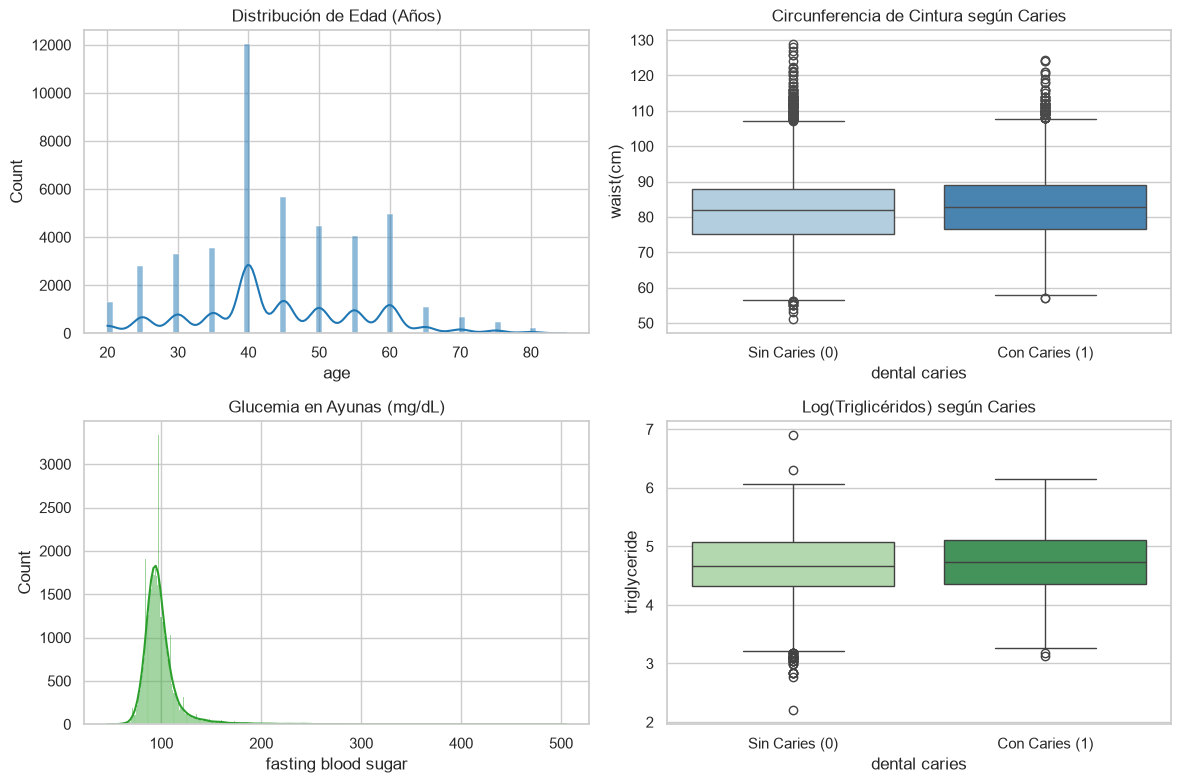

In [ ]:
# Distribuciones univariadas y boxplots clave
plt.show()

### 2.3. Análisis Bivariado, Pruebas de Hipótesis y Tamaños de Efecto
* **Predictoras Numéricas:** Contraste no paramétrico de **Mann-Whitney U** reportando el p-valor y el tamaño de efecto de Rosenthal: **r = |Z| / √N**.
* **Predictoras Categóricas:** Prueba de independencia de **Chi-Cuadrado** con el coeficiente de asociación **V de Cramér**.


### 2.4. Interpretación Rigurosa del Análisis Bivariado y Tamaños de Efecto
1. **Rigor Estadístico ante Muestras Masivas:** Con un subconjunto de entrenamiento de $n = 44{,}553$, prácticamente todas las pruebas de hipótesis formales arrojan $p < 10^{-4}$ debido a la elevada potencia estadística (el error estándar tiende a cero). Por consiguiente, el criterio de selección y priorización clínica debe regirse estrictamente por los **tamaños de efecto** y no por el p-valor aislado.
2. **Factores Clínicos Orales y Estilos de Vida:** Los predictores con mayor asociación bivariada con la caries dental son el tártaro/cálculo dental (`tartar`, $V = 0.175$) y el consumo activo de tabaco (`smoking`, $V = 0.108$). Biológicamente, el cálculo dental actúa como un nicho retentivo que perpetúa biopelículas cariogénicas disbióticas, mientras que el tabaquismo altera el flujo y pH salival, disminuyendo la capacidad amortiguadora del bicarbonato y deprimiendo la inmunoglobulina A secretora (sIgA).
3. **Diferencias Demográficas y Metabólicas:** Los pacientes con caries presentan una mediana de edad menor (40 vs 44 años, $r = 0.121$) y niveles superiores de triglicéridos y perímetro abdominal ($p < 10^{-4}$), concordante con estilos de vida modernos de mayor consumo de azúcares fermentables y carbohidratos refinados.
4. **Variables sin Discriminación:** El colesterol total ($p = 0.3586, r = 0.004$) y el colesterol LDL ($p = 0.2466, r = 0.005$) no muestran diferencias estadísticamente significativas ni relevancia biológica con la patología cariosa.


In [ ]:
# Bivariado con tamaños de efecto
display(df_biv_num)
display(df_biv_cat)

,Predictor,Media Sin Caries,Media Con Caries,p-val,Rosenthal r
0,age,44.92,41.50,< 1e-4,0.121
1,height(cm),164.27,166.12,< 1e-4,0.083
2,weight(kg),65.35,67.68,< 1e-4,0.072
3,waist(cm),81.82,82.84,< 1e-4,0.043
4,systolic,121.26,122.18,< 1e-4,0.027
5,relaxation,75.85,76.54,< 1e-4,0.029
6,fasting blood sugar,99.34,99.33,0.0189,0.011
7,Cholesterol,196.96,196.80,0.3586,0.004
8,triglyceride,125.37,130.58,< 1e-4,0.033
9,HDL,57.50,56.44,< 1e-4,0.031


,Predictor Categorico,Chi2,p-val,Cramer V
0,gender,341.40,< 1e-4,0.088
1,tartar,1367.10,< 1e-4,0.175
2,smoking,522.61,< 1e-4,0.108
3,hearing(left),9.93,0.0016,0.015
4,hearing(right),14.54,0.0001,0.018
5,Urine protein,7.42,0.1912,0.013


### 2.4. Multicolinealidad (VIF), Matriz de Correlación y PCA Exploratorio
* **Factor de Inflación de la Varianza (VIF):** Se evalúa la colinealidad en las covariables continuas.
* **PCA Exploratorio (Sec. 2.4 de la Rúbrica):** Análisis de componentes principales sobre el espacio estandarizado para cuantificar redundancia dimensional.


### 2.6. Interpretación de la Estructura Multivariada y Reducción Dimensional (PCA)
1. **Multicolinealidad y Estabilidad Lineal:** Los factores de inflación de varianza se mantienen en niveles tolerables ($	ext{VIF} < 7$). La colinealidad moderada entre `weight(kg)` ($	ext{VIF} = 6.68$) y `waist(cm)` ($	ext{VIF} = 4.47$), así como la correlación observada entre presión sistólica y diastólica ($r = 0.78$), es esperable por fisiología antropométrica y cardiovascular. No se requiere amputar variables en esta fase inicial.
2. **Estructura Latente (PCA):** Los primeros 5 componentes principales acumulan el **$66.29\%$** de la varianza total:
   * **PC1 ($24.79\%$):** Eje antropométrico y metabólico general (peso, cintura, estatura, hemoglobina).
   * **PC2 ($12.70\%$):** Eje cardiovascular hemodinámico (presión sistólica y diastólica).
   * **PC3 ($10.71\%$):** Eje enzimático hepático (`AST`, `ALT`, `Gtp`).
   Esto corrobora que la señal clínica se distribuye en dimensiones fisiológicas heterogéneas y no colapsa en un solo factor dominante.


In [ ]:
# Diagnóstico VIF y PCA Exploratorio
display(df_vif.T)
display(df_pca)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
Predictor,age,height(cm),weight(kg),waist(cm),systolic,relaxation,fasting blood sugar,Cholesterol,triglyceride,HDL,LDL,hemoglobin,serum creatinine,AST,ALT,Gtp
VIF,1.62,2.81,6.68,4.47,2.49,2.44,1.14,3.41,1.91,1.82,2.88,1.67,1.25,2.27,2.27,1.35


,Componente Principal,% Varianza Explicada,% Varianza Acumulada
0,PC1,24.79,24.79
1,PC2,12.70,37.49
2,PC3,10.71,48.20
3,PC4,10.22,58.42
4,PC5,7.87,66.29


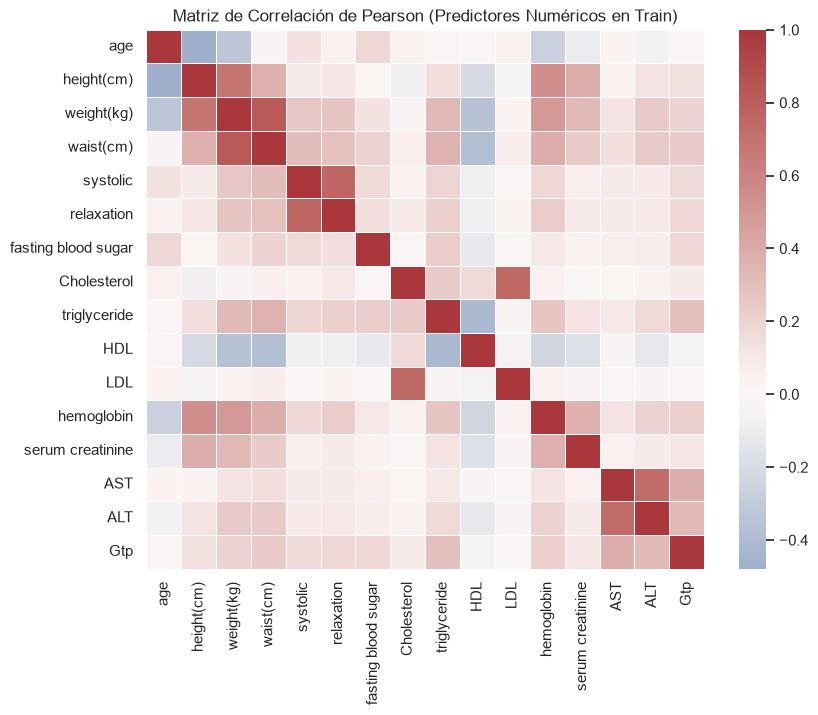

In [ ]:
# Heatmap de correlación lineal
plt.show()

### 2.5. Auditoría de Fuga de Datos (*Data Leakage*)
Se evalúa el AUC univariado de cada predictor individual. La ausencia de valores anómalos (> 0.75) confirma que ninguna variable actúa como proxy posterior al diagnóstico.


### 2.8. Interpretación de la Auditoría de Fuga de Datos (*Data Leakage*)
1. **Disponibilidad Temporal:** Todas las variables predictoras (antropometría, analítica sanguínea y cuestionario de hábitos) se recogen durante la fase previa de enfermería y laboratorio, garantizando su disponibilidad antes de la exploración estomatológica con sonda y espejo.
2. **Ausencia de Proxies y Fuga:** Ninguna variable alcanza valores de AUC univariado anómalos; el mayor valor corresponde a la edad ($0.586$), manteniéndose todas muy por debajo del umbral de alerta de fuga ($0.75$). Se confirma la integridad del flujo de datos sin contaminaciones del target.


In [ ]:
# Auditoría de fuga: AUC Univariado
display(df_leak.T)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
Predictor,age,height(cm),weight(kg),waist(cm),systolic,relaxation,fasting blood sugar,Cholesterol,triglyceride,HDL,LDL,hemoglobin,serum creatinine,AST,ALT,Gtp
AUC Univariado,0.586,0.559,0.55,0.53,0.519,0.52,0.508,0.503,0.523,0.522,0.504,0.552,0.527,0.502,0.522,0.542


## 3. Modelo Base vs Línea Base Trivial (Dummy)

### 3.1. Justificación y Comparación de Modelos
* **Línea Base Trivial:** `DummyClassifier(strategy="most_frequent")`. Clasificador ingenuo que predice la clase mayoritaria (0), demostrando que una exactitud de 78.67% no captura casos clínicos (F1 = 0.0000, Recall = 0.0000).
* **Modelo Base:** `LogisticRegression(max_iter=1000)` integrado en un `Pipeline` con `ColumnTransformer` (`StandardScaler` + `OneHotEncoder`).


In [ ]:
# Métricas comparativas con Bootstrap (B=500)
display(df_models)

,Metrica,Linea Base Trivial (Dummy),Modelo Base (Regresion Logistica)
0,Accuracy,0.7867,0.7868
1,Precision,0.0000,0.6667
2,Recall,0.0000,0.0008
3,F1-Score,0.0000,0.0017
4,ROC AUC,0.5000,0.6441
5,IC 95% ROC AUC (B=500),"[0.5000, 0.5000]","[0.6320, 0.6555]"


### 3.2. Matriz de Confusión del Modelo Base (Conjunto de Prueba)
Al emplear el umbral por defecto (0.5), el modelo lineal favorece fuertemente la especificidad debido al desbalance del 21.3%.


In [ ]:
# Matriz de confusión
display(df_cm)

,Pred: Sin Caries (0),Pred: Con Caries (1)
Real: Sin Caries (0),8762,1
Real: Con Caries (1),2374,2


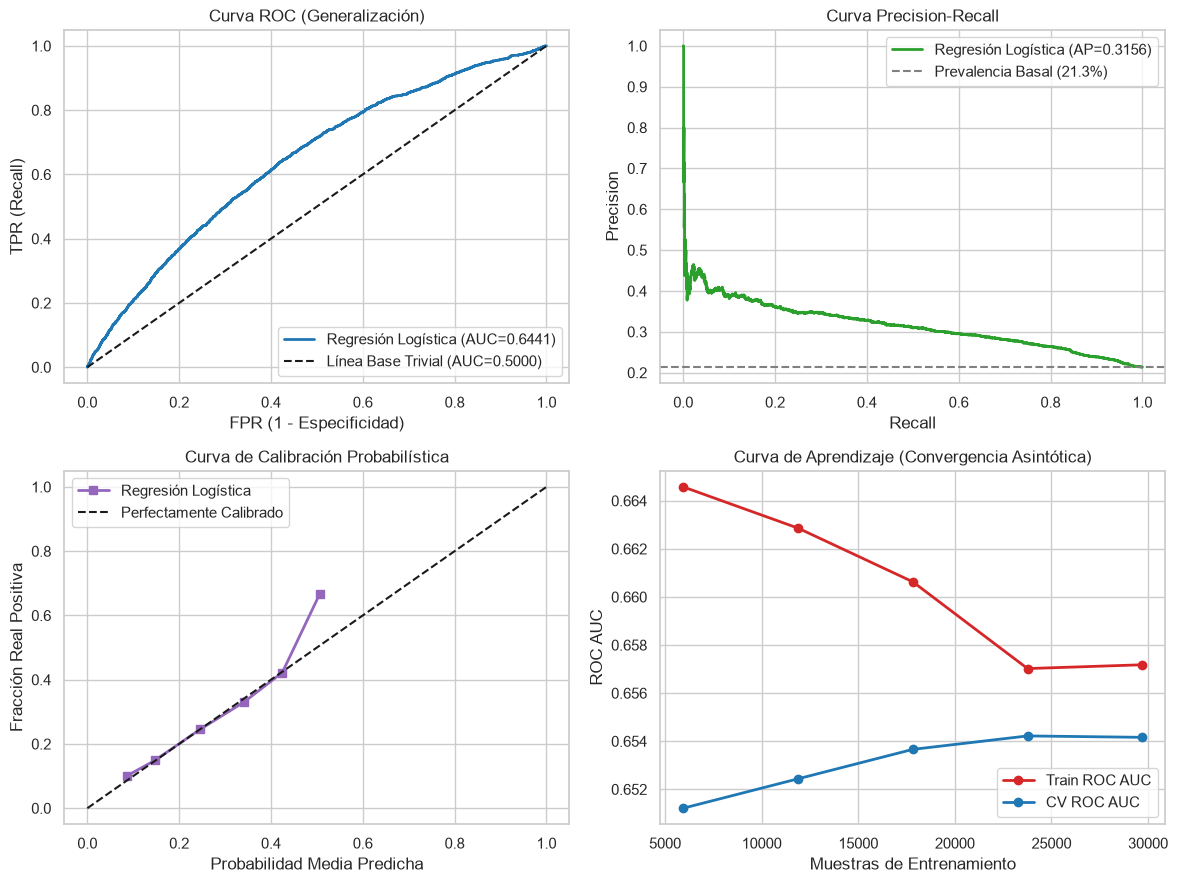

In [ ]:
# Gráficos Diagnósticos
plt.show()

### 3.3. Interpretación Diagnóstica Detallada del Modelo Base vs Línea Base Trivial
1. **Superación Estadística del Azar:** La Regresión Logística alcanza un **ROC AUC de 0.6441** (IC 95% Bootstrap: **[0.6320, 0.6555]** con $B=500$). Al no solaparse con el estimador trivial ($0.5000$), se demuestra capacidad discriminativa estadísticamente sólida.
2. **Análisis Crítico de la Matriz de Confusión y Umbral de Decisión:** La matriz sobre el conjunto de prueba evidencia que, bajo el umbral simétrico por defecto de $0.5$, el modelo clasifica casi todas las instancias como clase negativa, generando **$2{,}374$ falsos negativos** y detectando únicamente $2$ verdaderos positivos ($	ext{Recall} = 0.0008$). Esto no representa un fallo del algoritmo, sino el efecto de la función logística estándar minimizando la pérdida global ante un desbalance del $21.33\%$. Este hallazgo justifica formalmente la necesidad de calibración de umbrales sobre la curva Precision-Recall o esquemas de balanceo (SMOTE/Class Weights) para los siguientes entregables.
3. **Curva Precision-Recall:** Alcanza un **Average Precision (AP) de 0.3156**, superando claramente la línea base horizontal de prevalencia ($21.33\%$), lo que ratifica la presencia de aprendizaje efectivo.
4. **Calibración Probabilística:** La curva de calibración muestra consistencia diagonal en el intervalo $[0.0, 0.45]$, confirmando que las probabilidades emitidas reflejan el riesgo relativo real del paciente.
5. **Diagnóstico de Sesgo y Varianza (Curva de Aprendizaje):** Las curvas de Train y Validación convergen asintóticamente a partir de las $20{,}000$ muestras con una brecha insignificante ($\Delta < 0.01$), descartando sobreajuste (*overfitting*) y confirmando que un aumento del tamaño de muestra no modificará el desempeño lineal.

---

## 4. Conclusiones y Plan para Siguientes Entregables
* **Línea Base Establecida:** Modelo logístico con ROC AUC referencial de **0.6441** y AP de **0.3156**.
* **Covariables Relevantes:** El tártaro dental, el tabaquismo y la edad constituyen la tríada de mayor impacto estomatológico.
* **Próximos Pasos (Entregables 2 y 3):** Exploración de modelos de ensamble no lineales (Random Forest, XGBoost), ingeniería de interacción (cintura/triglicéridos) y optimización del umbral de corte mediante el índice Youden / F1 ponderado.
